# First Implementation 


There is the pipeline
**camera.py**: builds the intrinsics for each pyramid level
**frameData.py**: stores image, derivatives, inverse depth, and pose
**pose_estimator_gauss_newton.py**: optimizes the pose
**common.py**: bilinear interpolation
**dataset/desktop_dataset/images**: input images
**Depth-Anything**: computes depth maps on the fly from the images


In this notebook, the simplest setup is now:

- you directly provide the path to the reference image
- you directly provide the path to the current image

You no longer need to use indices such as `scene_000`, `scene_001`, and so on.


In [1]:
from pathlib import Path
import copy
import hashlib
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.transforms import Compose

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent

PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

import importlib.util
try:
    import camera
except ModuleNotFoundError:
    camera_path = SCRIPT_DIR / "camera.py"
    if camera_path.exists():
        spec = importlib.util.spec_from_file_location("camera", str(camera_path))
        camera = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(camera)
        sys.modules["camera"] = camera
    else:
        raise
import common
import frameData
import pose_estimator_gauss_newton


In [2]:
plt.rcParams["figure.figsize"] = (8, 5)
np.set_printoptions(precision=6, suppress=True)

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
DEPTH_ANYTHING_DIR = PROJECT_ROOT / "Depth-Anything"

if not DEPTH_ANYTHING_DIR.exists():
    raise FileNotFoundError(f"Depth-Anything not found: {DEPTH_ANYTHING_DIR}")

if str(DEPTH_ANYTHING_DIR) not in sys.path:
    sys.path.insert(0, str(DEPTH_ANYTHING_DIR))

from depth_anything.dpt import DepthAnything
from depth_anything.util.transform import NormalizeImage, PrepareForNet, Resize



c:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:


DEPTH_ENCODER = "vitb"
DEPTH_MODEL_NAME = f"LiheYoung/depth_anything_{DEPTH_ENCODER}14"
DEPTH_CACHE_DIR = SCRIPT_DIR / "depth_anything_cache" / DEPTH_ENCODER
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEPTH_CACHE_DIR.mkdir(parents=True, exist_ok=True)


--------------

### Convert to frame, create a list of these frames

In [4]:
import convert_video_frame
convert_video_frame.video_to_frames_and_save(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\fake.mp4", r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\frames_fake")

FPS : 24.0
Nombre total de trames : 121
121 frames sauvegardees dans : C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\frames_fake


In [5]:
dossier_fake = Path(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\frames_fake")


In [6]:
fake_frame_paths = sorted(
    str(f.resolve())
    for f in dossier_fake.rglob("*")
    if f.is_file()
)

print(f"{len(fake_frame_paths)} fichiers trouvés dans {dossier_fake}")

121 fichiers trouvés dans C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\frames_fake


In [7]:

KEYFRAME_PATH = fake_frame_paths[0]
TARGET_PATH= fake_frame_paths[1]

print(KEYFRAME_PATH)
print(TARGET_PATH)

C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\frames_fake\frame_00000.png
C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\frames_fake\frame_00001.png


## 2. Notebook utility functions

Here we rewrite a few small helper functions to make the pipeline explicit:

- load a grayscale image from its path
- compute a depth map with Depth Anything
- convert depth -> inverse depth
- quickly display a 4x4 matrix

The depth is inferred directly from the corresponding image with the `vitb` encoder, and can optionally be cached in `depth_anything_cache/vitb` to avoid recomputing it every time.

The important conversion is:

$$
\rho = \frac{1}{d}
$$

where **d** is the depth and **rho** is the inverse depth expected by the solver.


In [8]:


#PERMET DE NORMALISER LE CHEMIN DE L'IMAGE, EN S'ASSURANT QU'IL EST ABSOLU ET QU'IL EXISTE
def normalize_image_path(path_like) -> Path:
    path = Path(path_like)
    if not path.is_absolute():
        path = (ROOT / path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    return path



#PERMET DE CONSTRUIRE LE CHEMIN DE CACHE POUR LA CARTE DE PROFONDEUR CORRESPONDANTE À UNE IMAGE, EN UTILISANT UN HASH DU CHEMIN DE L'IMAGE POUR ÉVITER LES CONFLITS
def build_depth_cache_path(image_path: Path) -> Path:
    safe_name = image_path.stem.replace(" ", "_")
    cache_key = hashlib.md5(str(image_path.resolve()).encode("utf-8")).hexdigest()[:8]
    cache_name = f"{safe_name}_{cache_key}_depth.npy"
    return DEPTH_CACHE_DIR / cache_name


#PERMET DE CHARGER UNE IMAGE EN NIVEAUX DE GRIS À PARTIR D'UN CHEMIN, EN UTILISANT OPENCV POUR LIRE LE FICHIER ET LE CONVERTIR EN UN TABLEAU NUMPY
def load_gray_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image = cv2.imdecode(buffer, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


def load_rgb_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image_bgr = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def get_depth_anything_components():
    if not hasattr(get_depth_anything_components, "model"):
        previous_cwd = Path.cwd()
        try:
            os.chdir(DEPTH_ANYTHING_DIR)
            model = DepthAnything.from_pretrained(DEPTH_MODEL_NAME).to(DEVICE).eval()
        finally:
            os.chdir(previous_cwd)

        transform = Compose([
            Resize(
                width=518,
                height=518,
                resize_target=False,
                keep_aspect_ratio=True,
                ensure_multiple_of=14,
                resize_method="lower_bound",
                image_interpolation_method=cv2.INTER_CUBIC,
            ),
            NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            PrepareForNet(),
        ])
        get_depth_anything_components.model = model
        get_depth_anything_components.transform = transform

        total_params = sum(param.numel() for param in model.parameters())
        print(f"Depth Anything loaded on {DEVICE} ({total_params / 1e6:.2f}M parameters)")

    return get_depth_anything_components.model, get_depth_anything_components.transform


def load_depth_map(image_path, use_cache: bool = True, save_cache: bool = True) -> np.ndarray:
    path = normalize_image_path(image_path)
    cache_path = build_depth_cache_path(path)
    if use_cache and cache_path.exists():
        return np.load(cache_path).astype(np.float32)

    image = load_rgb_image(path).astype(np.float32) / 255.0
    h, w = image.shape[:2]

    model, transform = get_depth_anything_components()
    image = transform({"image": image})["image"]
    image = torch.from_numpy(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        depth = model(image)

    depth = F.interpolate(depth[None], (h, w), mode="bilinear", align_corners=False)[0, 0]
    depth = depth.cpu().numpy().astype(np.float32)

    if save_cache:
        np.save(cache_path, depth)

    return depth


def depth_to_invdepth(depth: np.ndarray):
    inv_depth = np.zeros_like(depth, dtype=np.float32)
    valid_mask = depth > 1e-6
    inv_depth[valid_mask] = 1.0 / depth[valid_mask]
    inv_depth_var = np.ones_like(depth, dtype=np.float32)
    inv_depth_var[~valid_mask] = 1e6
    return inv_depth, inv_depth_var, valid_mask


def show_pose_matrix(title: str, pose):
    matrix = pose.as_matrix()
    print(title)
    print(matrix)
    return matrix


(832, 1104)


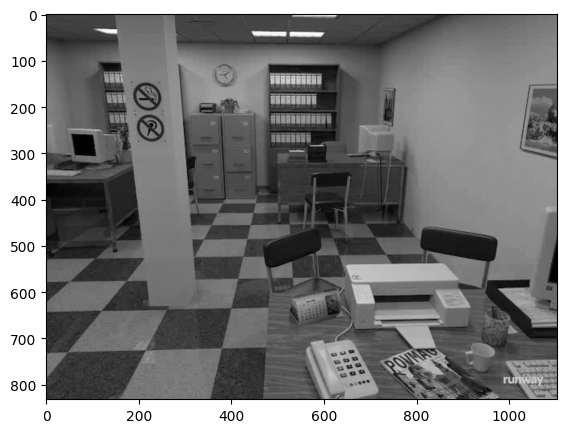

In [9]:
frame_0 = load_gray_image(KEYFRAME_PATH)
print(frame_0.shape)
plt.imshow(frame_0, cmap='gray')

## keyframe

Here we load:

- the reference image specified in `KEYFRAME_PATH`
- the depth map inferred by **Depth Anything** for this image

This image provides the base 3D geometry.


In [10]:
keyframe_image_path = normalize_image_path(KEYFRAME_PATH)
keyframe_image = load_gray_image(keyframe_image_path)
keyframe_depth = load_depth_map(keyframe_image_path)
keyframe_inv_depth, keyframe_inv_depth_var, valid_mask = depth_to_invdepth(keyframe_depth)


In [11]:

print("keyframe_image_path =", keyframe_image_path)
print("keyframe_image shape =", keyframe_image.shape, "dtype =", keyframe_image.dtype)
print("keyframe_depth shape =", keyframe_depth.shape, "dtype =", keyframe_depth.dtype)
print("depth min/max =", float(keyframe_depth.min()), float(keyframe_depth.max()))
print("valid depth ratio =", float(valid_mask.mean()))


keyframe_image_path = C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\frames_fake\frame_00000.png
keyframe_image shape = (832, 1104) dtype = uint8
keyframe_depth shape = (832, 1104) dtype = float32
depth min/max = 1.390641689300537 84.03084564208984
valid depth ratio = 1.0


Text(0.5, 1.0, 'Inverse depth')

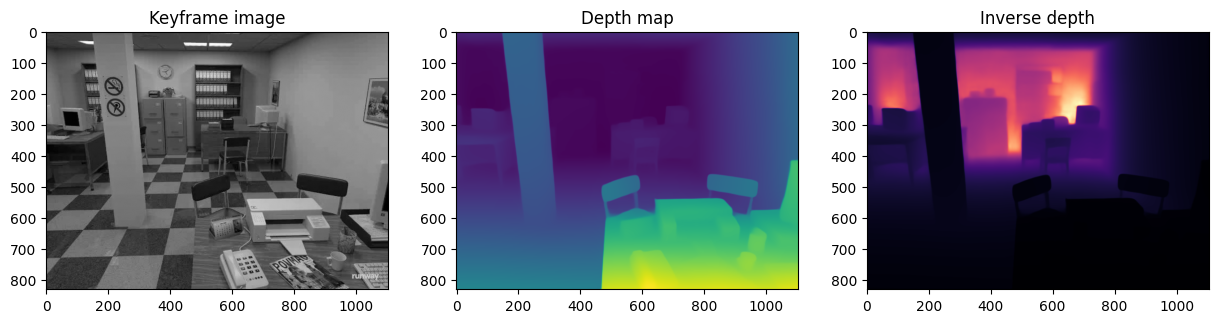

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))




axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title("Keyframe image")

axes[1].imshow(keyframe_depth, cmap="viridis")
axes[1].set_title("Depth map")


axes[2].imshow(keyframe_inv_depth, cmap="magma")
axes[2].set_title("Inverse depth")




## 4. Intrinsics

Dans ce notebook, les intrinseques doivent etre definies **une seule fois** dans la cellule suivante.

Idee simple :
- tu choisis `USER_FX`, `USER_FY`, `USER_CX`, `USER_CY`
- ces valeurs sont la **source de verite**
- elles sont passees a `camera.camera(...)`
- ensuite on affiche clairement ce que le pipeline utilise vraiment

Important :
- `frameData.py` et `camera.py` redimensionnent tout vers la resolution interne definie dans `params.py`
- donc on affiche a la fois :
  - `K_user` = la matrice que tu choisis
  - `K_used_lvl0` = la matrice effectivement utilisee au niveau 0 de la pyramide

Comme ca, il n'y a plus d'ambiguite sur les intrinseques utilisees dans la suite du notebook.


In [ ]:

import base64
from IPython.display import HTML
with open(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\capture.png","rb") as f:
    with open(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\capture.png","rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    HTML(f'<div style="text-align:center;"><img src="data:image/png;base64,{b64}" width="900"/></div>')
HTML(f'<div style="text-align:center;"><img src="data:image/png;base64,{b64}" width="900"/></div>')

NameError: name 'HTML' is not defined

In [ ]:
# ==================================================
# Intrinseques a definir UNE FOIS au debut
# ==================================================
loaded_height, loaded_width = keyframe_image.shape[:2]

# Mets ici les intrinseques que tu veux utiliser.
# Ce bloc est la source de verite pour tout le notebook.
USER_WIDTH = loaded_width
USER_HEIGHT = loaded_height


#Pour Emanuel
USER_FX = 481.20 * 1.725
USER_FY = 480.0 * 1.73333
USER_CX = 319.5 * 1.725
USER_CY = 239.5 * 1.73333


#Pour tum RGB
#USER_FX = 525.0  # focal length x
#USER_FY = 525.0  # focal length y
#USER_CX = 319.5  # optical center x
#USER_CY = 239.5  # optical center y




intrinsics_user = {
    "width": USER_WIDTH,
    "height": USER_HEIGHT,
    "fx": USER_FX,
    "fy": USER_FY,
    "cx": USER_CX,
    "cy": USER_CY,
}

K_user = np.array([
    [USER_FX, 0.0, USER_CX],
    [0.0, USER_FY, USER_CY],
    [0.0, 0.0, 1.0],
], dtype=np.float64)

cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    USER_WIDTH,
    USER_HEIGHT,
)

intrinsics_used_lvl0 = {
    "width": cam.width[0],
    "height": cam.height[0],
    "fx": cam.fx[0],
    "fy": cam.fy[0],
    "cx": cam.cx[0],
    "cy": cam.cy[0],
}

K_used_lvl0 = np.array([
    [cam.fx[0], 0.0, cam.cx[0]],
    [0.0, cam.fy[0], cam.cy[0]],
    [0.0, 0.0, 1.0],
], dtype=np.float64)

print("Loaded keyframe size:")
print("  width  =", loaded_width)
print("  height =", loaded_height)
print()
print("USER intrinsics chosen at the beginning of the notebook:")
print(intrinsics_user)
print()
print("K_user =")
print(K_user)
print()
print("Internal working resolution used by the pipeline (level 0):")
print("  width  =", intrinsics_used_lvl0["width"])
print("  height =", intrinsics_used_lvl0["height"])
print()
print("K_used_lvl0 =")
print(K_used_lvl0)


Loaded keyframe size:
  width  = 1104
  height = 832

USER intrinsics chosen at the beginning of the notebook:
{'width': 1104, 'height': 832, 'fx': 481.2, 'fy': 480.0, 'cx': 319.5, 'cy': 239.5}

K_user =
[[481.2   0.  319.5]
 [  0.  480.  239.5]
 [  0.    0.    1. ]]

Internal working resolution used by the pipeline (level 0):
  width  = 640
  height = 480

K_used_lvl0 =
[[278.956522   0.       185.217391]
 [  0.       276.923077 138.173077]
 [  0.         0.         1.      ]]


In [ ]:
scale_x = cam.width[0] / USER_WIDTH
scale_y = cam.height[0] / USER_HEIGHT

print("Check that the pipeline camera really comes from the USER intrinsics above:")
print("  scale_x =", scale_x)
print("  scale_y =", scale_y)
print()
print("  USER_FX -> cam.fx[0] :", USER_FX, "->", cam.fx[0])
print("  USER_FY -> cam.fy[0] :", USER_FY, "->", cam.fy[0])
print("  USER_CX -> cam.cx[0] :", USER_CX, "->", cam.cx[0])
print("  USER_CY -> cam.cy[0] :", USER_CY, "->", cam.cy[0])
print()
print("Expected level-0 values after internal resize:")
print("  expected fx =", USER_FX * scale_x)
print("  expected fy =", USER_FY * scale_y)
print("  expected cx =", USER_CX * scale_x)
print("  expected cy =", USER_CY * scale_y)

assert np.isclose(cam.fx[0], USER_FX * scale_x)
assert np.isclose(cam.fy[0], USER_FY * scale_y)
assert np.isclose(cam.cx[0], USER_CX * scale_x)
assert np.isclose(cam.cy[0], USER_CY * scale_y)

print()
print("Assertion passed: the notebook is using the intrinsics defined above.")


Check that the pipeline camera really comes from the USER intrinsics above:
  scale_x = 0.5797101449275363
  scale_y = 0.5769230769230769

  USER_FX -> cam.fx[0] : 481.2 -> 278.95652173913044
  USER_FY -> cam.fy[0] : 480.0 -> 276.9230769230769
  USER_CX -> cam.cx[0] : 319.5 -> 185.21739130434784
  USER_CY -> cam.cy[0] : 239.5 -> 138.1730769230769

Expected level-0 values after internal resize:
  expected fx = 278.95652173913044
  expected fy = 276.9230769230769
  expected cx = 185.21739130434784
  expected cy = 138.1730769230769

Assertion passed: the notebook is using the intrinsics defined above.


### Verification for every pyramid level

On affiche maintenant les intrinseques utilisees a **chaque niveau** de la pyramide, et on verifie qu elles correspondent bien a la regle automatique du code : division par `2**lvl` a partir du niveau 0.

In [ ]:
intrinsics_per_level = []
base_fx = cam.fx[0]
base_fy = cam.fy[0]
base_cx = cam.cx[0]
base_cy = cam.cy[0]
base_width = cam.width[0]
base_height = cam.height[0]

print("Intrinsics used for each pyramid level:")
print()

for lvl in range(len(cam.fx)):
    scale = 2 ** lvl
    expected_fx = base_fx / scale
    expected_fy = base_fy / scale
    expected_cx = base_cx / scale
    expected_cy = base_cy / scale
    expected_width = int(base_width / scale)
    expected_height = int(base_height / scale)

    K_lvl = np.array([
        [cam.fx[lvl], 0.0, cam.cx[lvl]],
        [0.0, cam.fy[lvl], cam.cy[lvl]],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    assert np.isclose(cam.fx[lvl], expected_fx)
    assert np.isclose(cam.fy[lvl], expected_fy)
    assert np.isclose(cam.cx[lvl], expected_cx)
    assert np.isclose(cam.cy[lvl], expected_cy)
    assert cam.width[lvl] == expected_width
    assert cam.height[lvl] == expected_height

    intrinsics_per_level.append({
        "level": lvl,
        "scale": scale,
        "width": cam.width[lvl],
        "height": cam.height[lvl],
        "fx": cam.fx[lvl],
        "fy": cam.fy[lvl],
        "cx": cam.cx[lvl],
        "cy": cam.cy[lvl],
        "K": K_lvl,
    })

    print(f"LEVEL {lvl}")
    print(f"  scale  = 1 / {scale}")
    print(f"  size   = {cam.width[lvl]} x {cam.height[lvl]}")
    print(f"  fx, fy = {cam.fx[lvl]:.6f}, {cam.fy[lvl]:.6f}")
    print(f"  cx, cy = {cam.cx[lvl]:.6f}, {cam.cy[lvl]:.6f}")
    print("  K =")
    print(K_lvl)
    print()

print("All assertions passed: each level uses the expected intrinsics.")


Intrinsics used for each pyramid level:

LEVEL 0
  scale  = 1 / 1
  size   = 640 x 480
  fx, fy = 278.956522, 276.923077
  cx, cy = 185.217391, 138.173077
  K =
[[278.956522   0.       185.217391]
 [  0.       276.923077 138.173077]
 [  0.         0.         1.      ]]

LEVEL 1
  scale  = 1 / 2
  size   = 320 x 240
  fx, fy = 139.478261, 138.461538
  cx, cy = 92.608696, 69.086538
  K =
[[139.478261   0.        92.608696]
 [  0.       138.461538  69.086538]
 [  0.         0.         1.      ]]

LEVEL 2
  scale  = 1 / 4
  size   = 160 x 120
  fx, fy = 69.739130, 69.230769
  cx, cy = 46.304348, 34.543269
  K =
[[69.73913   0.       46.304348]
 [ 0.       69.230769 34.543269]
 [ 0.        0.        1.      ]]

LEVEL 3
  scale  = 1 / 8
  size   = 80 x 60
  fx, fy = 34.869565, 34.615385
  cx, cy = 23.152174, 17.271635
  K =
[[34.869565  0.       23.152174]
 [ 0.       34.615385 17.271635]
 [ 0.        0.        1.      ]]

LEVEL 4
  scale  = 1 / 16
  size   = 40 x 30
  fx, fy = 17.434783, 17

In [ ]:

keyframe = frameData.frameData()
keyframe.setImage(keyframe_image)
keyframe.setInvDepth(keyframe_inv_depth, keyframe_inv_depth_var)

print("Pyramid levels =", len(keyframe.image))
for lvl in range(len(keyframe.image)):
    print(
        f"level {lvl}: image={keyframe.image[lvl].shape}, "
        f"invDepth={keyframe.invDepth[lvl].shape}, "
        f"grad={keyframe.imageDerivative[lvl].shape}"
    )


Pyramid levels = 5
level 0: image=(480, 640), invDepth=(480, 640), grad=(480, 640, 2)
level 1: image=(240, 320), invDepth=(240, 320), grad=(240, 320, 2)
level 2: image=(120, 160), invDepth=(120, 160), grad=(120, 160, 2)
level 3: image=(60, 80), invDepth=(60, 80), grad=(60, 80, 2)
level 4: image=(30, 40), invDepth=(30, 40), grad=(30, 40, 2)


## 5. Loading the current image

Now we take a second image, specified in `TARGET_PATH`.

This is the image whose relative pose with respect to the keyframe we want to estimate.
At first, its pose is the identity, and then the solver updates it.


In [ ]:
current_image_path = normalize_image_path(TARGET_PATH)
current_image = load_gray_image(current_image_path)

current_frame = frameData.frameData()
current_frame.setImage(current_image)



### Recap

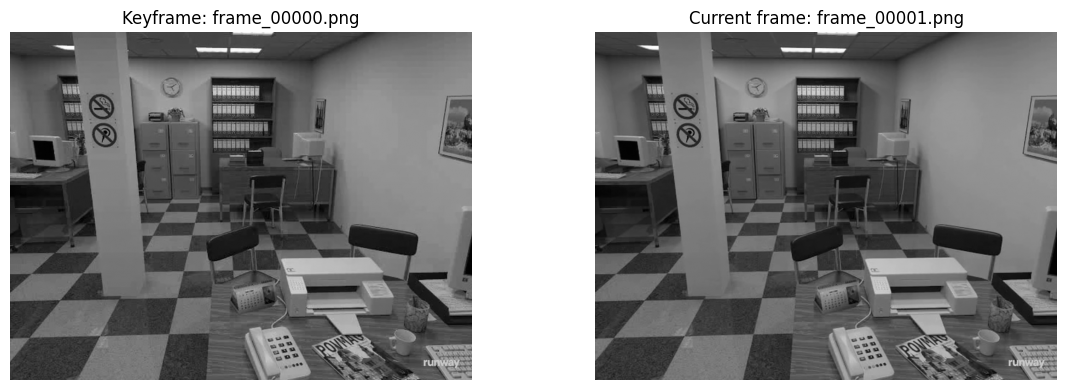

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title(f"Keyframe: {keyframe_image_path.name}")


axes[1].imshow(current_image, cmap="gray")
axes[1].set_title(f"Current frame: {current_image_path.name}")


for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## Initial pose and optimization updates

Dans la cellule suivante, `pose_solver` est cree avec `cam`.
Donc les intrinseques utilisees pour l'estimation de pose sont bien celles affichees juste au-dessus.


In [ ]:
pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(cam, show_debug=False)

print("Proof before optimization:")
print("  pose_solver.camera is cam ->", pose_solver.camera is cam)
print("  pose_solver.camera.fx[0] =", pose_solver.camera.fx[0])
print("  pose_solver.camera.fy[0] =", pose_solver.camera.fy[0])
print("  pose_solver.camera.cx[0] =", pose_solver.camera.cx[0])
print("  pose_solver.camera.cy[0] =", pose_solver.camera.cy[0])
print()
print("Reference level-0 intrinsics that should match:")
print(intrinsics_used_lvl0)
print()

initial_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
initial_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
initial_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Initial photometric errors before optimization:")
print("  level 4 =", initial_error_lvl4)
print("  level 3 =", initial_error_lvl3)
print("  level 2 =", initial_error_lvl2)


Proof before optimization:
  pose_solver.camera is cam -> True
  pose_solver.camera.fx[0] = 278.95652173913044
  pose_solver.camera.fy[0] = 276.9230769230769
  pose_solver.camera.cx[0] = 185.21739130434784
  pose_solver.camera.cy[0] = 138.1730769230769

Reference level-0 intrinsics that should match:
{'width': 640, 'height': 480, 'fx': 278.95652173913044, 'fy': 276.9230769230769, 'cx': 185.21739130434784, 'cy': 138.1730769230769}

Initial photometric errors before optimization:
  level 4 = 97.64880382775061
  level 3 = 82.81643046944147
  level 2 = 95.49119906123242


**optPose(...)** performs several updates:

- it computes an error
- it locally linearizes the problem
- it computes a pose increment
- it accepts or rejects this update depending on the error improvement

At the end, **current_frame.pose** contains the estimated extrinsic matrix of the current frame relative to the keyframe.


In [ ]:
pose_solver.optPose(current_frame, keyframe)

final_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
final_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
final_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Final photometric errors after optimization:")
print("  level 4 =", final_error_lvl4)
print("  level 3 =", final_error_lvl3)
print("  level 2 =", final_error_lvl2)


lvl:  4  initial error:  97.64880382775061
 error improvement too small, level converged! it:  2  error:  91.85915680337858  lambda:  0.0
lvl:  3  initial error:  78.00222106388152
 error improvement too small, level converged! it:  3  error:  73.36425125695703  lambda:  0.2
lvl:  2  initial error:  71.71607314213254
 error improvement too small, level converged! it:  2  error:  70.50436133670635  lambda:  219902325555.2
Final photometric errors after optimization:
  level 4 = 93.76995029405865
  level 3 = 73.79583121540956
  level 2 = 70.50436133670635


### Sanity check on pose estimation

Ici on verifie que le resultat a du sens :
- les erreurs photometriques doivent baisser apres optimisation
- la pose finale doit contenir des valeurs finies
- on veut aussi garder une trace interpretable du gain obtenu a chaque niveau.

In [ ]:
optimization_summary = {
    "lvl4_initial": float(initial_error_lvl4),
    "lvl4_final": float(final_error_lvl4),
    "lvl3_initial": float(initial_error_lvl3),
    "lvl3_final": float(final_error_lvl3),
    "lvl2_initial": float(initial_error_lvl2),
    "lvl2_final": float(final_error_lvl2),
}

error_improvement = {
    "lvl4": float(initial_error_lvl4 - final_error_lvl4),
    "lvl3": float(initial_error_lvl3 - final_error_lvl3),
    "lvl2": float(initial_error_lvl2 - final_error_lvl2),
}

print("Optimization summary:")
for lvl in [4, 3, 2]:
    initial_value = optimization_summary[f"lvl{lvl}_initial"]
    final_value = optimization_summary[f"lvl{lvl}_final"]
    improvement = error_improvement[f"lvl{lvl}"]
    print(f"  level {lvl}: initial={initial_value:.6f}, final={final_value:.6f}, improvement={improvement:.6f}")

pose_matrix_now = current_frame.pose.as_matrix()
pose_is_finite = bool(np.isfinite(pose_matrix_now).all())
errors_improved = {lvl: (error_improvement[f"lvl{lvl}"] > 0.0) for lvl in [4, 3, 2]}

print()
print("Pose matrix finite ->", pose_is_finite)
print("Errors improved by level ->", errors_improved)

assert pose_is_finite, "Pose matrix contains non-finite values."
assert all(errors_improved.values()), "At least one pyramid level did not improve after optimization."

print()
print("Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.")


Optimization summary:
  level 4: initial=97.648804, final=93.769950, improvement=3.878854
  level 3: initial=82.816430, final=73.795831, improvement=9.020599
  level 2: initial=95.491199, final=70.504361, improvement=24.986838

Pose matrix finite -> True
Errors improved by level -> {4: True, 3: True, 2: True}

Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.


### Output matrix: the final extrinsic matrix

This is the most important output of the notebook.

This 4x4 matrix represents the estimated relative pose of the current image with respect to the keyframe.

In block form:

$$
T =
\begin{bmatrix}
R & t \\
0 & 1
\end{bmatrix}
$$


In [ ]:
extrinsic_matrix = show_pose_matrix(
    f"Extrinsic matrix for {current_image_path.name} relative to {keyframe_image_path.name}:",
    current_frame.pose,
)


Extrinsic matrix for frame_00001.png relative to frame_00000.png:
[[ 0.999997 -0.00143  -0.001733  0.001037]
 [ 0.001431  0.999999  0.000412 -0.001855]
 [ 0.001732 -0.000415  0.999998 -0.002917]
 [ 0.        0.        0.        1.      ]]


--
Comparaison avec le GT

In [ ]:
GT_Pose = np.array([
    [0.999994773, -0.001180835, -0.002703893, -0.017635176],
    [0.001167188,  0.999986898, -0.005040318, -0.021989598],
    [0.002709795,  0.005037578,  0.999983107,  0.000817620],
    [0.0,          0.0,          0.0,          1.0],
], dtype=np.float64)


Difference = extrinsic_matrix - GT_Pose
A = np.round(Difference, 2)  # 1 chiffre après la virgule

print(A)

[[ 0.   -0.    0.    0.02]
 [ 0.    0.    0.01  0.02]
 [-0.   -0.01  0.   -0.  ]
 [ 0.    0.    0.    0.  ]]


----------- 

## Evaluation

On garde maintenant **une seule metrique** : la **photometric error**.

Definition :
- on reprojecte chaque pixel valide du keyframe dans l image courante
- on compare l intensite du keyframe a l intensite observee apres reprojection
- on prend la difference au carre
- on somme sur tous les pixels valides



In [ ]:
def compute_photometric_error(frame, keyframe, cam, lvl=0):
    width = cam.width[lvl]
    height = cam.height[lvl]
    fx = cam.fx[lvl]
    fy = cam.fy[lvl]
    cx = cam.cx[lvl]
    cy = cam.cy[lvl]
    fxinv = cam.fxinv[lvl]
    fyinv = cam.fyinv[lvl]
    cxinv = cam.cxinv[lvl]
    cyinv = cam.cyinv[lvl]

    relativePose = frame.pose.dot(keyframe.pose.inv())

    squared_error_map = np.full((height, width), np.nan, dtype=np.float32)
    valid_mask = np.zeros((height, width), dtype=bool)

    for y in range(height):
        for x in range(width):
            invDepth = keyframe.invDepth[lvl][y, x]
            if invDepth <= 0.0:
                continue

            pointKeyframe = np.array([fxinv * x + cxinv, fyinv * y + cyinv, 1.0]) / invDepth
            pointFrame = relativePose.dot(pointKeyframe)

            if pointFrame[2] <= 0.0:
                continue

            pixelFrame = np.array([
                fx * pointFrame[0] / pointFrame[2] + cx,
                fy * pointFrame[1] / pointFrame[2] + cy,
            ])
            if pixelFrame[0] < 1.0 or pixelFrame[0] >= width - 1 or pixelFrame[1] < 1.0 or pixelFrame[1] >= height - 1:
                continue

            key_intensity = float(keyframe.image[lvl][y, x])
            observed_intensity = float(common.getSubPixelValue(frame.image[lvl], pixelFrame))
            squared_error = (key_intensity - observed_intensity) ** 2

            squared_error_map[y, x] = squared_error
            valid_mask[y, x] = True

    photometric_error = float(np.nansum(squared_error_map[valid_mask]))

    return {
        "photometric_error": photometric_error,
        "squared_error_map": squared_error_map,
        "valid_mask": valid_mask,
        "level": lvl,
    }


In [ ]:
evaluation = compute_photometric_error(current_frame, keyframe, cam, lvl=0)

In [ ]:
photometric_error = evaluation["photometric_error"]

print("Photometric error =", photometric_error)


Photometric error = 7853490.0


In [ ]:
abs_error_map = np.sqrt(evaluation["squared_error_map"])
valid_mask = evaluation["valid_mask"]

valid_abs_errors = abs_error_map[valid_mask]

total_valid_pixels = int(valid_abs_errors.size)
num_gt_200 = int(np.sum(valid_abs_errors > 200))
num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))





num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))








print("Pixel count by absolute difference range:")
print("  total valid pixels       =", total_valid_pixels)
print("  difference > 200         =", num_gt_200)
print("  150 <= difference <= 200 =", num_150_200)
print("  100 <= difference < 150  =", num_100_150)
print("   50 <= difference < 100  =", num_50_100)
print("   30 <= difference < 50   =", num_30_50)
print("   10 <= difference < 30   =", num_10_30)
print("    0 <= difference < 10   =", num_0_10)


Pixel count by absolute difference range:
  total valid pixels       = 304747
  difference > 200         = 0
  150 <= difference <= 200 = 1
  100 <= difference < 150  = 27
   50 <= difference < 100  = 287
   30 <= difference < 50   = 1158
   10 <= difference < 30   = 10723
    0 <= difference < 10   = 292551


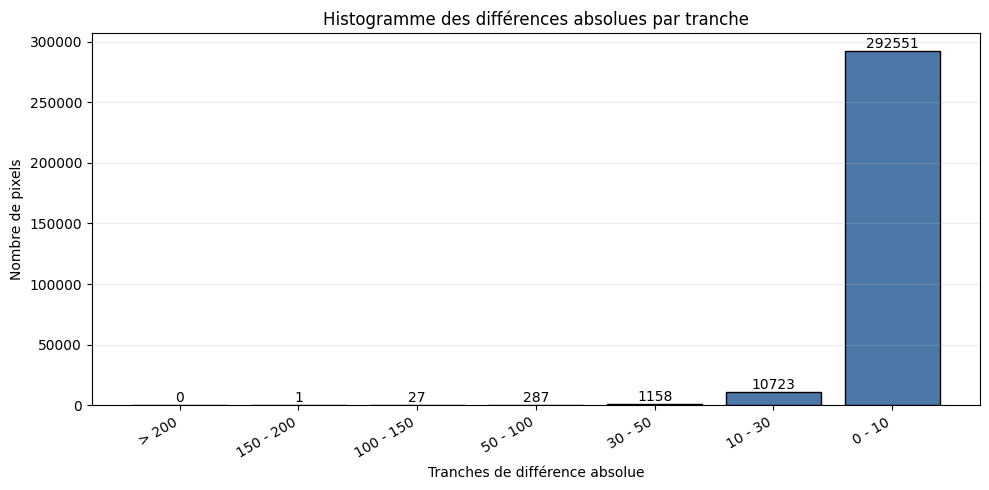

In [ ]:
range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

range_counts = [
    num_gt_200,
    num_150_200,
    num_100_150,
    num_50_100,
    num_30_50,
    num_10_30,
    num_0_10,
]

plt.figure(figsize=(10, 5))
bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
plt.title("Histogramme des différences absolues par tranche")
plt.xlabel("Tranches de différence absolue")
plt.ylabel("Nombre de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, count in zip(bars, range_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


### Squared photometric error map

Cette figure n ajoute pas une nouvelle metrique.
Elle sert seulement a voir **ou** l erreur photometrique se concentre dans l image.


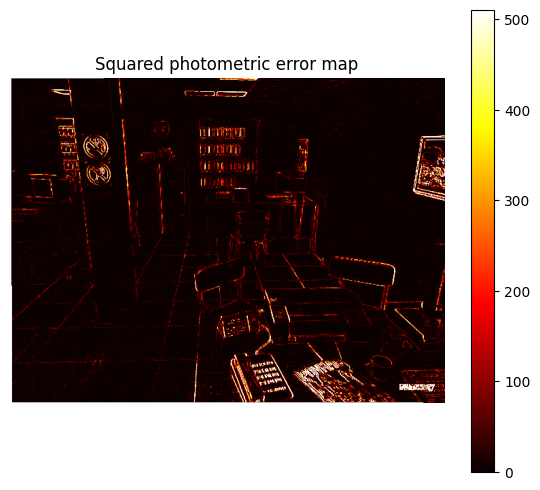

In [ ]:
squared_error_map = evaluation["squared_error_map"]
valid_mask = evaluation["valid_mask"]

valid_values = squared_error_map[valid_mask]
vmax_sq = float(np.nanpercentile(valid_values, 99)) if valid_values.size > 0 else 1.0

plt.figure(figsize=(7, 6))
plt.imshow(squared_error_map, cmap="hot", vmin=0, vmax=vmax_sq)
plt.title("Squared photometric error map")
plt.axis("off")
plt.colorbar()
plt.show()


In [ ]:
print("Only evaluation metric used in this notebook:")
print("  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels")


Only evaluation metric used in this notebook:
  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels


------
## Scale sur toutes les images

In [ ]:
print(fake_frame_paths[0])

C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\ai\TUM_fake_frames\frame_00000.png


Sequence fake:
  source size = 1104 x 832
  working size level-0 = 640 x 480
  fx level-0 = 278.95652173913044
  fy level-0 = 276.9230769230769

[fake] frame 0 -> keyframe de reference: frame_00000.png
lvl:  4  initial error:  97.64880382775061
 error improvement too small, level converged! it:  2  error:  91.85915680337858  lambda:  0.0
lvl:  3  initial error:  78.00222106388152
 error improvement too small, level converged! it:  3  error:  73.36425125695703  lambda:  0.2
lvl:  2  initial error:  71.71607314213254
 error improvement too small, level converged! it:  2  error:  70.50436133670635  lambda:  219902325555.2
[fake] frame 1 -> frame_00001.png | sum error = 7853490.00 | mean abs error = 2.2825 | valid pixels = 304747


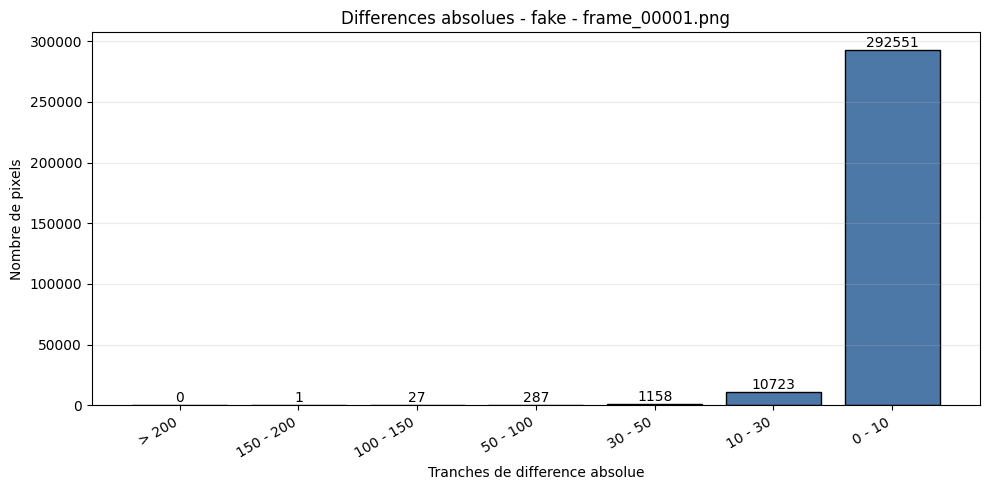

lvl:  4  initial error:  193.35598086124332
update too small, level converged! it:  4  error:  167.55844616689868  lambda:  14073748835532.8
lvl:  3  initial error:  153.7033748858724
 error improvement too small, level converged! it:  3  error:  145.1016445946349  lambda:  0.0
lvl:  2  initial error:  98.15133359937896
update too small, level converged! it:  2  error:  94.85398734712841  lambda:  14073748835532.8
[fake] frame 2 -> frame_00002.png | sum error = 19541168.00 | mean abs error = 3.5385 | valid pixels = 304470


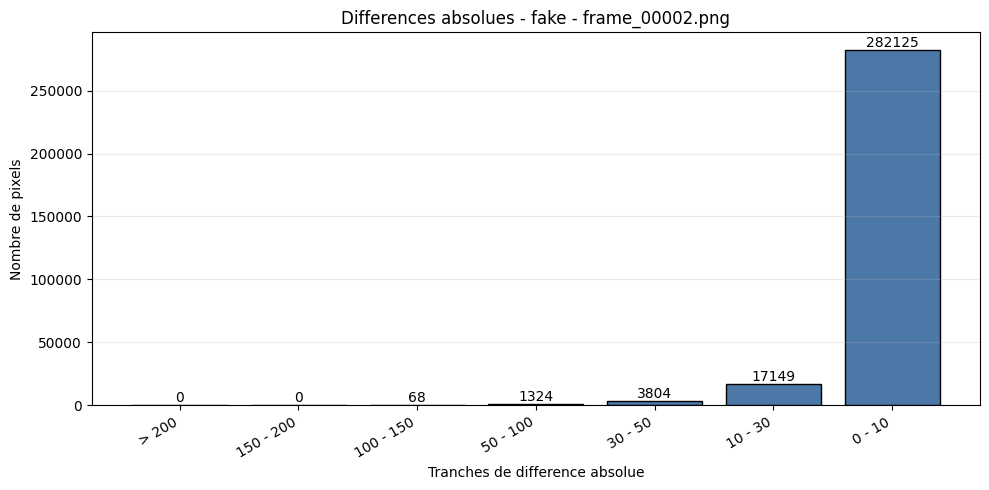

lvl:  4  initial error:  277.62870813397046
 error improvement too small, level converged! it:  5  error:  233.0512254691501  lambda:  0.0
lvl:  3  initial error:  210.2550318535226
 error improvement too small, level converged! it:  4  error:  187.7967337384933  lambda:  0.8
lvl:  2  initial error:  143.15277326890285
 error improvement too small, level converged! it:  2  error:  141.84643835529874  lambda:  7036874417766.4
[fake] frame 3 -> frame_00003.png | sum error = 34111912.00 | mean abs error = 4.6513 | valid pixels = 304018


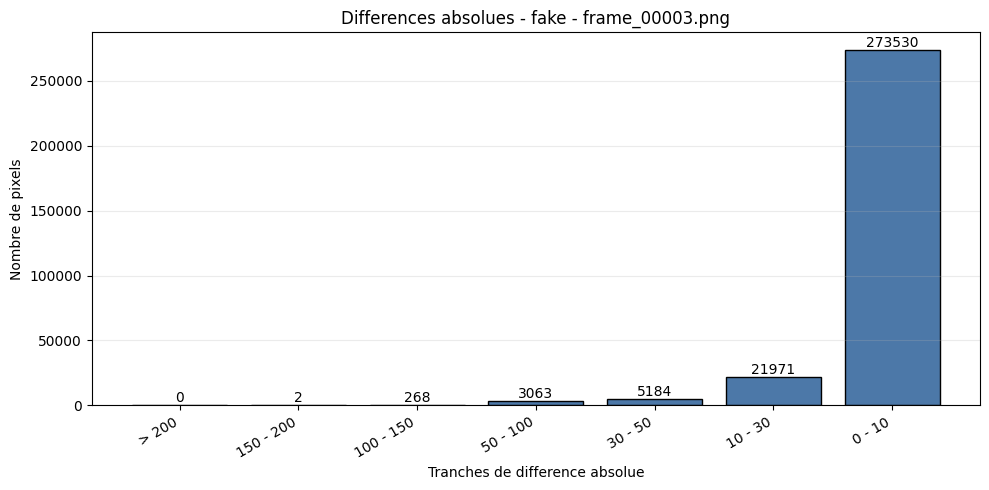

lvl:  4  initial error:  360.87942583731973
 error improvement too small, level converged! it:  5  error:  289.610714230253  lambda:  0.8
lvl:  3  initial error:  237.30898807231262
 error improvement too small, level converged! it:  4  error:  204.40099219608507  lambda:  0.1
lvl:  2  initial error:  180.2538302925757
 error improvement too small, level converged! it:  2  error:  171.2251868213967  lambda:  102.4
[fake] frame 4 -> frame_00004.png | sum error = 48923980.00 | mean abs error = 5.7085 | valid pixels = 303412


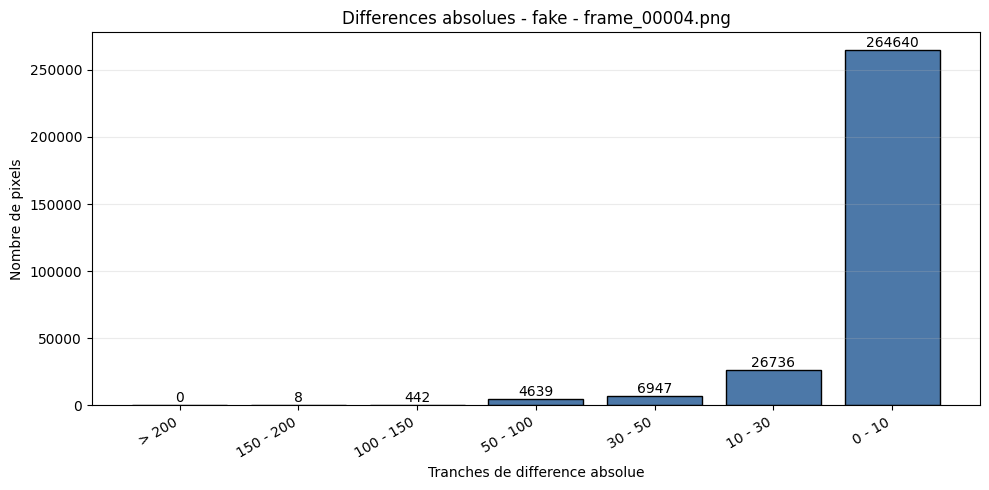

lvl:  4  initial error:  413.98181818181763
 error improvement too small, level converged! it:  6  error:  322.02302591821353  lambda:  0.0
lvl:  3  initial error:  269.4588528495161
 error improvement too small, level converged! it:  2  error:  237.64966290760205  lambda:  3518437208883.2
lvl:  2  initial error:  193.91491654696105
 error improvement too small, level converged! it:  2  error:  191.6249258404458  lambda:  0.0
[fake] frame 5 -> frame_00005.png | sum error = 61417280.00 | mean abs error = 6.3861 | valid pixels = 303039


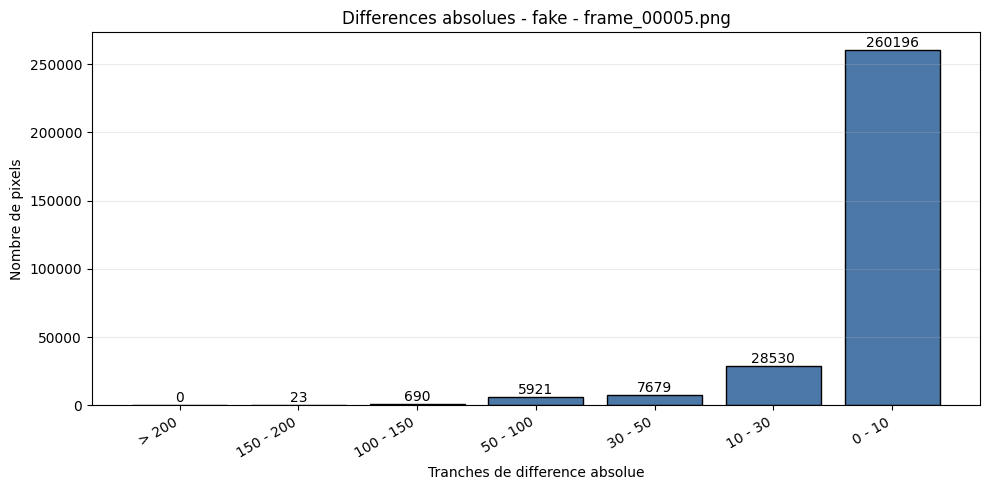

lvl:  4  initial error:  3982.3339712918655
 error improvement too small, level converged! it:  18  error:  2081.014153001204  lambda:  12.8
lvl:  3  initial error:  2360.6255847734546
 error improvement too small, level converged! it:  11  error:  2181.0092304976474  lambda:  0.0
lvl:  2  initial error:  2335.7894315746307
 error improvement too small, level converged! it:  3  error:  2317.046542487375  lambda:  0.0
[fake] frame 6 -> frame_00006.png | sum error = 521094688.00 | mean abs error = 37.4654 | valid pixels = 210661


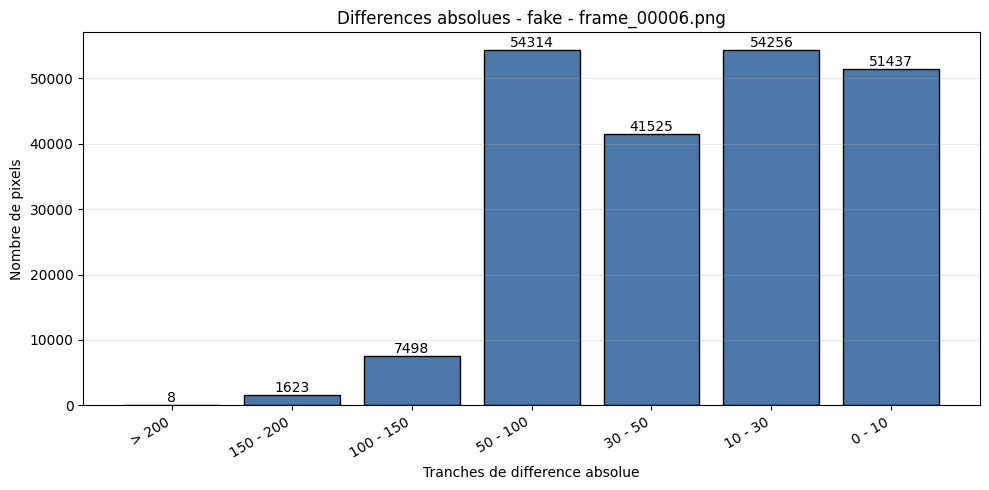

lvl:  4  initial error:  566.90909090909
update too small, level converged! it:  1  error:  566.90909090909  lambda:  900719925474099.2
lvl:  3  initial error:  2461.034981427091
 error improvement too small, level converged! it:  39  error:  294.78644973095714  lambda:  1759218604441.6
lvl:  2  initial error:  255.7981863190859
update too small, level converged! it:  2  error:  251.248611226663  lambda:  28147497671065.6
[fake] frame 7 -> frame_00007.png | sum error = 82674400.00 | mean abs error = 7.6404 | valid pixels = 301790


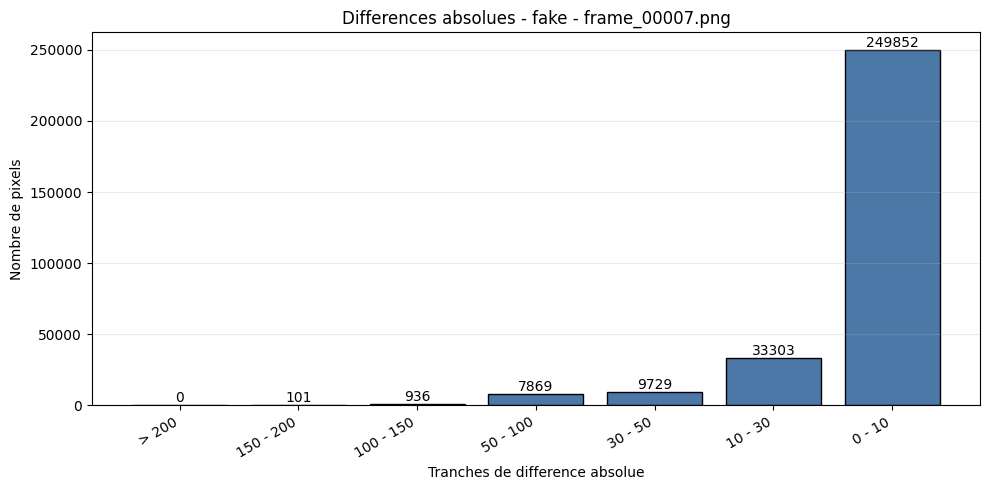

lvl:  4  initial error:  624.9741626794254
 error improvement too small, level converged! it:  7  error:  387.80042275380583  lambda:  0.0
lvl:  3  initial error:  326.19343102042455
 error improvement too small, level converged! it:  2  error:  294.0876139251698  lambda:  0.1
lvl:  2  initial error:  295.3725762021589
 error improvement too small, level converged! it:  2  error:  280.32622520298827  lambda:  0.0
[fake] frame 8 -> frame_00008.png | sum error = 90885800.00 | mean abs error = 8.1315 | valid pixels = 301317


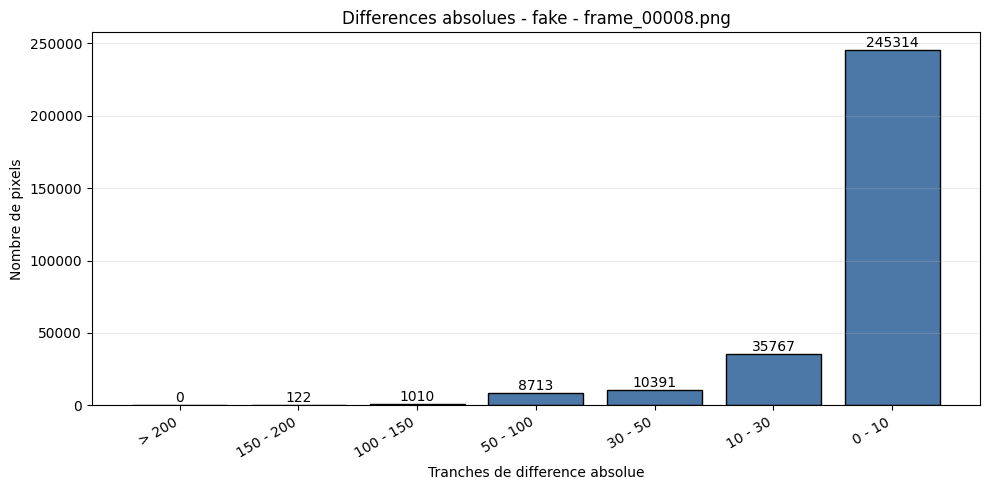

lvl:  4  initial error:  748.4095693779893
 error improvement too small, level converged! it:  5  error:  420.25658361254085  lambda:  0.2
lvl:  3  initial error:  321.16160593206297
update too small, level converged! it:  3  error:  293.6593744467379  lambda:  56294995342131.2
lvl:  2  initial error:  319.4991621947254
 error improvement too small, level converged! it:  2  error:  303.77643623535545  lambda:  0.0
[fake] frame 9 -> frame_00009.png | sum error = 99612088.00 | mean abs error = 8.6280 | valid pixels = 300682


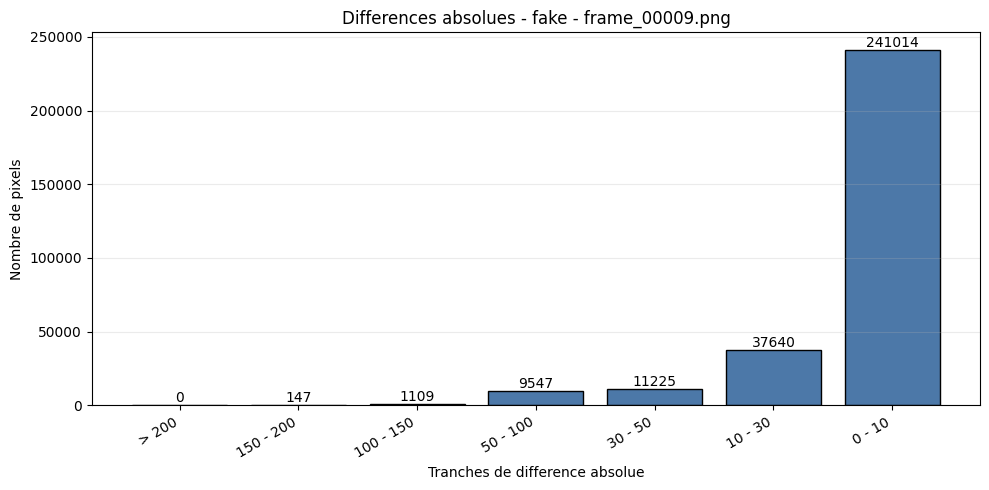

lvl:  4  initial error:  846.5358851674632
 error improvement too small, level converged! it:  5  error:  447.4678900081409  lambda:  0.0
lvl:  3  initial error:  344.1596266109452
 error improvement too small, level converged! it:  2  error:  311.08821522829675  lambda:  1759218604441.6
lvl:  2  initial error:  335.5564768293291
 error improvement too small, level converged! it:  2  error:  321.9336920204563  lambda:  0.0
[fake] frame 10 -> frame_00010.png | sum error = 107613088.00 | mean abs error = 9.0626 | valid pixels = 300254


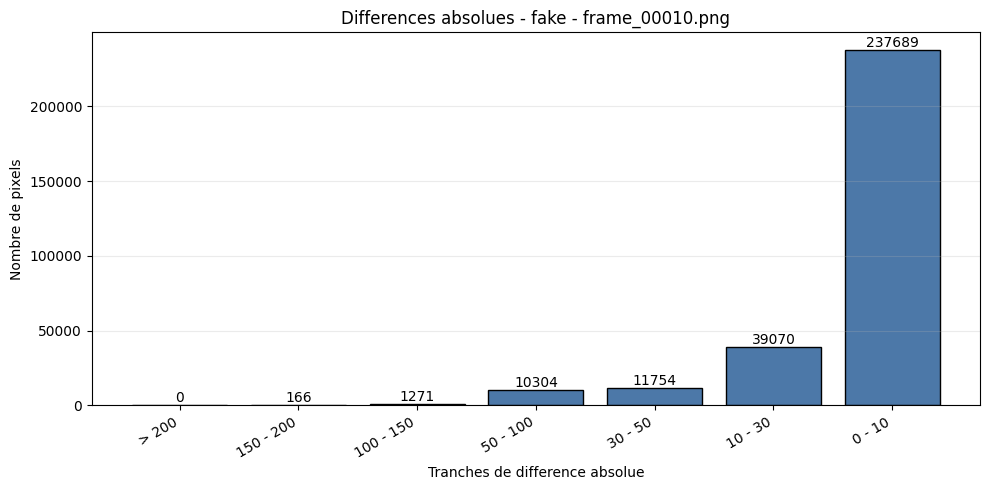

lvl:  4  initial error:  937.7980861244007
 error improvement too small, level converged! it:  5  error:  454.7377721195089  lambda:  0.1
lvl:  3  initial error:  360.0850730896916
 error improvement too small, level converged! it:  2  error:  327.26964382758246  lambda:  6.4
lvl:  2  initial error:  374.05621482137843
 error improvement too small, level converged! it:  2  error:  364.8337856615201  lambda:  1.6
[fake] frame 11 -> frame_00011.png | sum error = 116252208.00 | mean abs error = 9.5253 | valid pixels = 299808


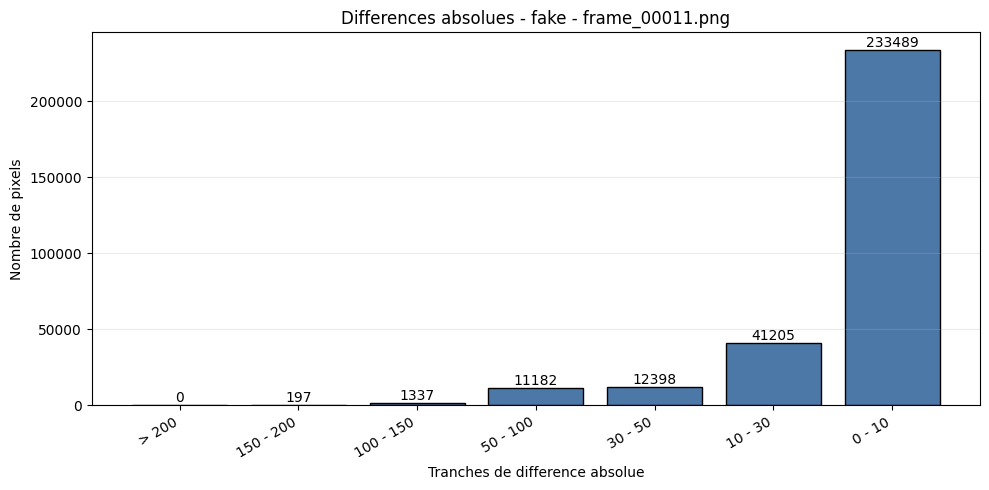

lvl:  4  initial error:  1009.6248803827735
 error improvement too small, level converged! it:  4  error:  484.63595146264976  lambda:  0.2
lvl:  3  initial error:  390.6199150190084
update too small, level converged! it:  2  error:  362.4022306842596  lambda:  56294995342131.2
lvl:  2  initial error:  406.84655413867176
 error improvement too small, level converged! it:  2  error:  394.1851160845791  lambda:  1759218604441.6
[fake] frame 12 -> frame_00012.png | sum error = 126038712.00 | mean abs error = 10.0872 | valid pixels = 299113


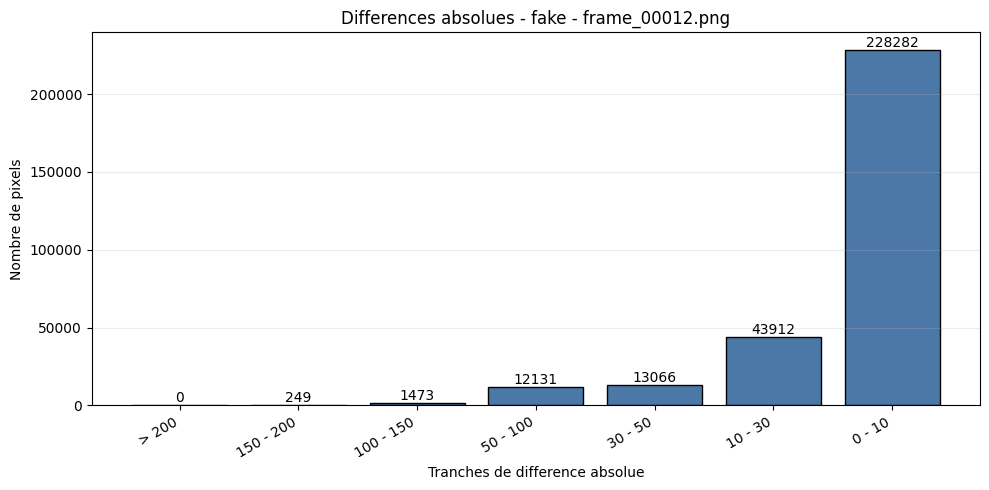

lvl:  4  initial error:  1088.289952153108
 error improvement too small, level converged! it:  4  error:  516.3987887920551  lambda:  6.4
lvl:  3  initial error:  435.365075381462
 error improvement too small, level converged! it:  2  error:  380.51578282456154  lambda:  439804651110.4
lvl:  2  initial error:  455.29048438557663
 error improvement too small, level converged! it:  2  error:  432.14849171966415  lambda:  0.0
[fake] frame 13 -> frame_00013.png | sum error = 133145504.00 | mean abs error = 10.4463 | valid pixels = 298630


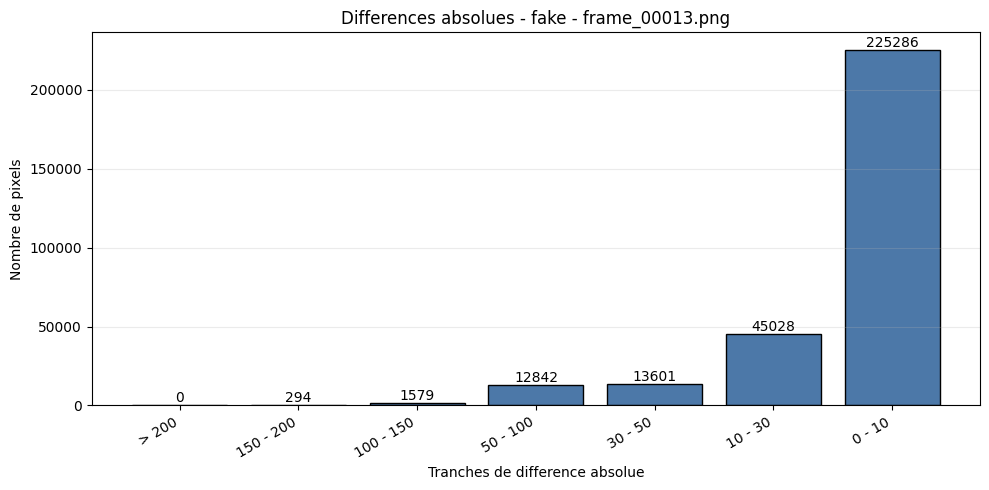

lvl:  4  initial error:  1185.7349282296632
 error improvement too small, level converged! it:  4  error:  558.0236155463311  lambda:  0.1
lvl:  3  initial error:  459.249982412393
 error improvement too small, level converged! it:  2  error:  411.14806155729093  lambda:  1.6
lvl:  2  initial error:  478.9108897751981
 error improvement too small, level converged! it:  2  error:  462.96246981796605  lambda:  3518437208883.2
[fake] frame 14 -> frame_00014.png | sum error = 143494736.00 | mean abs error = 11.0488 | valid pixels = 297992


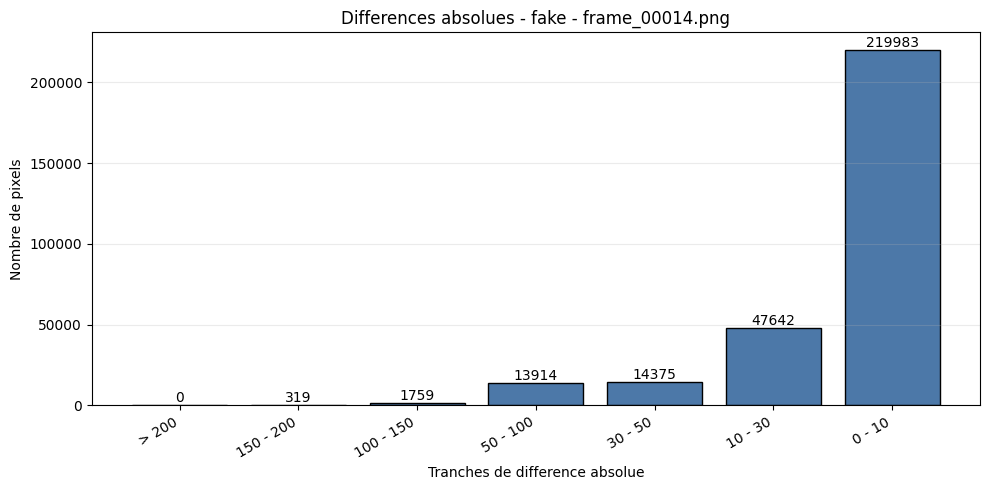

In [ ]:
# Boucle simple sur toute la sequence: depth estimation puis pose estimation par frame.
# Cette version reconstruit une camera coherente pour la sequence traitee
# et reinitialise le solveur pour eviter de reutiliser un etat precedent.
frame_paths = fake_frame_paths[:15]

if len(frame_paths) < 2:
    raise ValueError("Il faut au moins 2 frames pour lancer le pipeline.")

sequence_name = "fake"
sequence_keyframe = None
sequence_results = []

first_image_path = normalize_image_path(frame_paths[0])
first_image = load_gray_image(first_image_path)
sequence_height, sequence_width = first_image.shape[:2]

sequence_cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    sequence_width,
    sequence_height,
)
sequence_pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(sequence_cam, show_debug=False)

print(f"Sequence {sequence_name}:")
print(f"  source size = {sequence_width} x {sequence_height}")
print(f"  working size level-0 = {sequence_cam.width[0]} x {sequence_cam.height[0]}")
print(f"  fx level-0 = {sequence_cam.fx[0]}")
print(f"  fy level-0 = {sequence_cam.fy[0]}")
print()

for step, image_path in enumerate(frame_paths):
    image_path = normalize_image_path(image_path)
    image = load_gray_image(image_path)

    if image.shape[:2] != (sequence_height, sequence_width):
        raise ValueError(
            f"Toutes les images de la sequence {sequence_name} doivent avoir la meme taille. "
            f"Attendu: {(sequence_height, sequence_width)}, obtenu: {image.shape[:2]} pour {image_path.name}"
        )

    depth_map = load_depth_map(image_path)
    inv_depth, inv_depth_var, depth_valid_mask = depth_to_invdepth(depth_map)

    current_frame = frameData.frameData()
    current_frame.setImage(image)
    current_frame.setInvDepth(inv_depth, inv_depth_var)

    if step == 0:
        sequence_keyframe = current_frame
        print(f"[{sequence_name}] frame {step} -> keyframe de reference: {image_path.name}")
        sequence_results.append({
            "index": step,
            "image_path": str(image_path),
            "depth_valid_ratio": float(depth_valid_mask.mean()),
            "pose_matrix": current_frame.pose.as_matrix(),
            "photometric_error": None,
            "photometric_error_mean": None,
            "valid_pixel_count": None,
        })
        continue

    sequence_pose_solver.optPose(current_frame, sequence_keyframe)
    evaluation = compute_photometric_error(current_frame, sequence_keyframe, sequence_cam, lvl=0)

    abs_error_map = np.sqrt(evaluation["squared_error_map"])
    valid_mask = evaluation["valid_mask"]
    valid_abs_errors = abs_error_map[valid_mask]
    valid_pixel_count = int(valid_abs_errors.size)
    photometric_error = float(evaluation["photometric_error"])
    photometric_error_mean = float(valid_abs_errors.mean()) if valid_pixel_count > 0 else None
    mean_error_display = f"{photometric_error_mean:.4f}" if photometric_error_mean is not None else "None"

    print(
        f"[{sequence_name}] frame {step} -> {image_path.name} | "
        f"sum error = {photometric_error:.2f} | "
        f"mean abs error = {mean_error_display} | "
        f"valid pixels = {valid_pixel_count}"
    )

    num_gt_200 = int(np.sum(valid_abs_errors > 200))
    num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
    num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
    num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))
    num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))
    num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))
    num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

    range_labels = [
        "> 200",
        "150 - 200",
        "100 - 150",
        "50 - 100",
        "30 - 50",
        "10 - 30",
        "0 - 10",
    ]

    range_counts = [
        num_gt_200,
        num_150_200,
        num_100_150,
        num_50_100,
        num_30_50,
        num_10_30,
        num_0_10,
    ]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
    plt.title(f"Differences absolues - {sequence_name} - {image_path.name}")
    plt.xlabel("Tranches de difference absolue")
    plt.ylabel("Nombre de pixels")
    plt.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=30, ha="right")

    for bar, count in zip(bars, range_counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(count),
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

    sequence_results.append({
        "index": step,
        "image_path": str(image_path),
        "depth_valid_ratio": float(depth_valid_mask.mean()),
        "pose_matrix": current_frame.pose.as_matrix(),
        "photometric_error": photometric_error,
        "photometric_error_mean": photometric_error_mean,
        "valid_pixel_count": valid_pixel_count,
    })


113761361.0


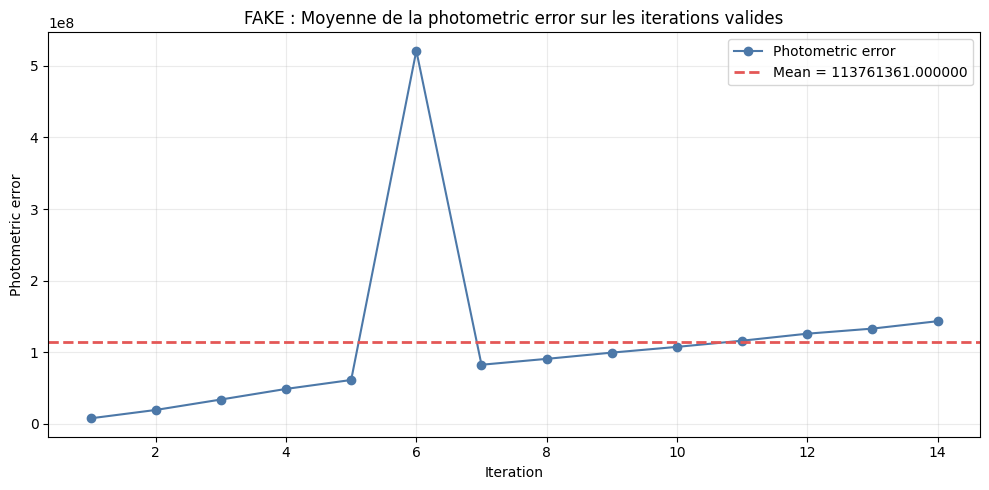

In [ ]:
valid_results = [
    item for item in sequence_results
    if item["photometric_error"] is not None
]

if not valid_results:
    raise ValueError("Aucun résultat valide disponible pour calculer la moyenne des erreurs photométriques.")

iteration_indices = [item["index"] for item in valid_results]
photometric_errors = [item["photometric_error"] for item in valid_results]
mean_photometric_error = float(np.mean(photometric_errors))

print(mean_photometric_error)

plt.figure(figsize=(10, 5))
plt.plot(iteration_indices, photometric_errors, marker="o", color="#4C78A8", label="Photometric error")
plt.axhline(
    mean_photometric_error,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_photometric_error:.6f}"
)
plt.title("FAKE : Moyenne de la photometric error sur les iterations valides")
plt.xlabel("Iteration")
plt.ylabel("Photometric error")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()